<a href="https://colab.research.google.com/github/Anaya2306/HackoWeek-SEM-5/blob/main/Week_9_%26_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, RocCurveDisplay)

In [3]:
# 1. LOAD DATASET & SIMULATE MISSING DATA

data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

np.random.seed(42)
mask = np.random.rand(*X.shape) < 0.05
X[mask] = np.nan

In [4]:
# 2. FEATURE ENGINEERING, SCALING & SPLIT

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),  # Handle missing data
    ('scaler', StandardScaler()),                   # Feature scaling
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))
])

In [5]:
# 3. CROSS-VALIDATION EVALUATION

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['precision', 'recall', 'f1', 'roc_auc']

cv_results = cross_validate(pipeline, X_train, y_train, cv=cv, scoring=scoring)

print("--- 5-Fold Cross-Validation Results (Train Set) ---")
for metric in scoring:
    scores = cv_results[f'test_{metric}']
    print(f"{metric.upper():<10}: {scores.mean():.4f} (+/- {scores.std():.4f})")

--- 5-Fold Cross-Validation Results (Train Set) ---
PRECISION : 0.9720 (+/- 0.0230)
RECALL    : 0.9614 (+/- 0.0205)
F1        : 0.9665 (+/- 0.0179)
ROC_AUC   : 0.9895 (+/- 0.0068)



--- Test Set Confusion Matrix ---
          Pred 0  Pred 1
Actual 0      39       3
Actual 1       4      68

--- Test Set Classification Report (Precision, Recall, F1) ---
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114

Test ROC-AUC Score: 0.9921


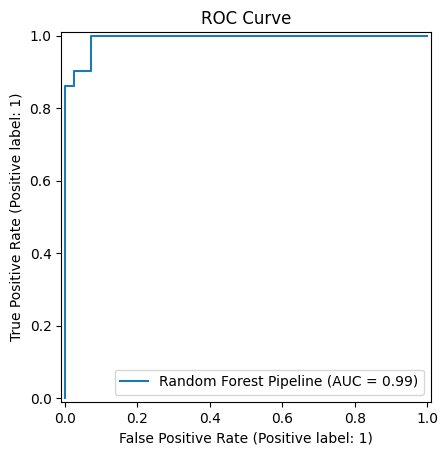

In [6]:
# 4. FINAL MODEL TEST EVALUATION

# Fit pipeline on entire training set and evaluate on test set
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("\n--- Test Set Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(pd.DataFrame(cm, index=['Actual 0', 'Actual 1'], columns=['Pred 0', 'Pred 1']))

print("\n--- Test Set Classification Report (Precision, Recall, F1) ---")
print(classification_report(y_test, y_pred, target_names=data.target_names))

test_roc_auc = roc_auc_score(y_test, y_proba)
print(f"Test ROC-AUC Score: {test_roc_auc:.4f}")

# Plot ROC Curve
RocCurveDisplay.from_predictions(y_test, y_proba, name="Random Forest Pipeline")
plt.title("ROC Curve")
plt.show()